# The SIDM background estimate from first principles — Part 1: the ABCD method, our variables, and the 2mu2e result

This notebook is the first of a series documenting the data-driven background
estimate for the SIDM (Self-Interacting Dark Matter) search in its two channels,
**4mu** and **2mu2e**. It is written to be readable start to finish without prior
knowledge of this analysis: every variable, cut, and sample is defined before it
is used.

**The series:**

| Part | Content |
|---|---|
| **1 (this notebook)** | The signal, the samples, the event selection, the ABCD method, the blinding scheme, and the deployed 2mu2e background estimate |
| **2** | The closure-test compendium: why every isolation-based ABCD plane fails in the 4mu channel — the instrumental artifact, the dimuon-vertex discriminant that isolates it, and the final 4mu verdict |
| **3 (forthcoming)** | Non-ABCD background methods under test for a unified 2mu2e + 4mu estimate: mJJ bump-hunt, MC-assisted shapes, and transfer factors |

**Provenance.** The ABCD region counts, closure ratios, predictions, and
survival fractions in this series are recomputed at execution time from the
merged histograms of the `AbcdVtx_Run2018_v1` Condor campaign (full 2018
DoubleMuon dataset, blinded channels; merged with
`sidm/scripts/merge_coffea_chunks_eos.py` to
`/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/abcd_vtx_run2018`, read here
from a local copy — see the README for the regeneration recipe). A few quoted
figures (the Z → μμ vertexing control and the cosmic-ray study) come from
standalone campaign scripts and are cited as such where used. The code that
filled these histograms is on this branch (`sidm/definitions/hists.py`,
`sidm/definitions/cuts.py`, `condor/`). Signal-region bins were never filled
for data — see the blinding section.

## 1. What we are looking for

The SIDM model predicts a dark bound state produced in pp collisions that decays
to a pair of **dark photons** ($Z_d$, also written $A'$), each of which decays back
to Standard-Model leptons. For the dark-photon masses we target (0.25–5 GeV), the
lepton pair from each dark photon is highly collimated: the opening angle scales
like $m_{Z_d}/p_T$. Reconstructed, each dark photon appears as a **lepton jet
(LJ)** — a narrow cluster of leptons and little else.

Two decay channels define our final states:

* **4mu** — both dark photons decay to $\mu^+\mu^-$: two **muon-type LJs**.
* **2mu2e** — one decays to muons, one to electrons: one **muon-type LJ** and one
  **EGM-type LJ** (EGM = "e-gamma", CMS's electron/photon reconstruction; the LJ
  contains electrons and/or photons — a displaced electron whose track is not
  reconstructed appears as a photon).

Muons enter the LJs in two flavors:

* **PF muons** — standard muons with an inner-tracker track (PF = particle flow,
  the global CMS event reconstruction). They carry tracker information, in
  particular **pixel hits** (hits in the innermost silicon layers).
* **DSA muons** — *displaced standalone* muons, reconstructed from the muon
  chambers alone. A muon born centimeters from the beamline leaves no pixel hits
  and may fail PF reconstruction entirely; DSA recovery is what gives this search
  sensitivity at long dark-photon lifetimes.

Because the dark photon can be long-lived ($c\tau$ from 0 up to ~100 mm in our
grid), the LJs can be **displaced**: their constituents originate away from the
primary vertex.

**Why the background must come from data.** After requiring two hard LJs there is
no irreducible Standard-Model process: the residual events are QCD multijet
fluctuations, mis-reconstructed muon pairs, and detector artifacts. None of these
are modeled reliably by simulation at the fidelity a search needs, so the
background under the signal must be estimated **from data itself**, with the
signal region hidden (blinded) until the method is frozen.

## 2. Samples

* **Data**: the full 2018 DoubleMuon dataset (eras A–D, 59.8 fb$^{-1}$), skimmed to
  our trigger + two-LJ preselection by the team:
  `/store/group/lpcmetx/SIDM/Data/2018data/Skims`. 2018 is the only year whose
  triggers cover this search — there is no usable 2016/2017 dataset for it.
* **Signal MC**: the SIDM grid over (bound-state mass, dark-photon mass $m_{Z_d}$,
  lifetime $c\tau$), in the same LLPNanoAOD format. Used for efficiency and
  signal-contamination checks — never for the background estimate.
* **Background MC** (Part 3 only): QCD $p_T$-binned dijet samples, Drell–Yan
  ($M_{\ell\ell}$ 10–50 and >50), $t\bar t$, and diboson (WW, WZ, ZZ) skims:
  `/store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims`. These exist to *test*
  whether MC can assist a background method, not to be subtracted blindly.

The cell below lists what is actually on disk in the merged cache — the data
samples per era and the signal grid points used in this campaign — and the
background sample list committed for the Part-3 campaign.

In [1]:
import glob, os, math, json
import numpy as np

CACHE = "/uscms_data/d3/murtazas/abcd_vtx_local"   # merged AbcdVtx_Run2018_v1 campaign

data_files = sorted(glob.glob(CACHE + "/DoubleMuon_*.coffea"))
sig_files  = sorted(glob.glob(CACHE + "/[24]Mu*.coffea"))
by_era = {}
for f in data_files:
    era = os.path.basename(f).replace(".coffea", "").split("_")[1]   # DoubleMuon_2018A_0 -> 2018A
    by_era[era] = by_era.get(era, 0) + 1
print("Merged data files per era:", by_era, " (total %d)" % len(data_files))
print("\nSignal grid points in this campaign (%d):" % len(sig_files))
for f in sig_files:
    print("  ", os.path.basename(f).replace(".coffea", ""))

from pathlib import Path
REPO = Path.cwd().parents[2]
print("\nBackground samples staged for the Part-3 method tests:")
print((REPO / "condor" / "abcd_bkg_samples.txt").read_text())

Merged data files per era: {'2018A': 3, '2018B': 14, '2018C': 1, '2018D': 50}  (total 68)

Signal grid points in this campaign (26):
   2Mu2E_1000GeV_1p2GeV_0p0096mm
   2Mu2E_1000GeV_1p2GeV_0p96mm
   2Mu2E_1000GeV_1p2GeV_9p6mm
   2Mu2E_100GeV_1p2GeV_0p096mm
   2Mu2E_100GeV_1p2GeV_96p0mm
   2Mu2E_100GeV_1p2GeV_9p6mm
   2Mu2E_500GeV_0p25GeV_0p4mm
   2Mu2E_500GeV_0p25GeV_4p0mm
   2Mu2E_500GeV_1p2GeV_0p019mm
   2Mu2E_500GeV_1p2GeV_19p0mm
   2Mu2E_500GeV_1p2GeV_1p9mm
   2Mu2E_500GeV_5p0GeV_80p0mm
   2Mu2E_500GeV_5p0GeV_8p0mm
   4Mu_1000GeV_1p2GeV_0p0096mm
   4Mu_1000GeV_1p2GeV_0p96mm
   4Mu_1000GeV_1p2GeV_9p6mm
   4Mu_100GeV_1p2GeV_0p096mm
   4Mu_100GeV_1p2GeV_96p0mm
   4Mu_100GeV_1p2GeV_9p6mm
   4Mu_500GeV_0p25GeV_0p4mm
   4Mu_500GeV_0p25GeV_4p0mm
   4Mu_500GeV_1p2GeV_0p019mm
   4Mu_500GeV_1p2GeV_19p0mm
   4Mu_500GeV_1p2GeV_1p9mm
   4Mu_500GeV_5p0GeV_80p0mm
   4Mu_500GeV_5p0GeV_8p0mm

Background samples staged for the Part-3 method tests:
QCD_Pt15To20
QCD_Pt20To30
QCD_Pt30To50
QCD_Pt50To80

## 3. Event selection

Histograms are filled by `sidm.tools.sidm_processor.SidmProcessor`, whose
selections ("channels") are named cut lists in `sidm/configs/selections.yaml`.
Rather than paraphrase them, the next cell prints the four channels used in this
campaign directly from the YAML — what you see is what ran.

Reading the printed cuts:

* **Object cuts** define which reconstructed objects may enter lepton jets:
  PF muons (looseID, $p_T>5$ GeV), DSA muons ($p_T>10$ GeV, displaced ID, plus a
  *segment-fraction < 1* overlap cut that drops DSA muons that are duplicates of
  an already-kept PF muon), electrons ($p_T>10$ GeV, `MVANonIsoWPL` — an
  identification working point that deliberately does **not** cut on isolation),
  and photons ($p_T>20$ GeV, custom cut-based ID with a pixel-seed requirement and
  a $\Delta R$ overlap veto against electrons).
* **Post-LJ cuts**: after clustering, keep LJs with $p_T>30$ GeV, $|\eta|<2.4$,
  and require muon-type LJs to contain at least two muons.
* **Event cuts**: the analysis trigger OR ("pass triggers"), a good
  primary-vertex filter, at least two LJs, and the channel topology — `4mu` means
  the two leading LJs are both muon-type; `2mu2e` means one muon-type + one
  EGM-type.
* The `_data_full` variants add exactly one thing: the **blind-box veto**
  (Section 6). Data only ever runs through these.

There are deliberately **no isolation or displacement cuts** at this stage — those
are the ABCD axes, and cutting on them here would sculpt the very planes we want
to measure.

In [2]:
import yaml
sel = yaml.safe_load(open(REPO / "sidm/configs/selections.yaml"))
for ch in ["4mu_abcd_scan", "2mu2e_abcd_scan",
           "4mu_abcd_scan_data_full", "2mu2e_abcd_scan_data_full"]:
    print("=" * 30, ch, "=" * 30)
    print(yaml.dump(sel[ch], default_flow_style=False))

============================== 4mu_abcd_scan ==============================
evt_cuts:
- - - - evt_cuts:
        - pass triggers
      - - PV filter
  - '>=2 LJs'
- 4mu
obj_cuts:
  dsaMuons:
  - pT > 10 GeV
  - '|eta| < 2.4'
  - displaced ID
  - all + segment fraction < 1
  electrons:
  - pT > 10 GeV
  - '|eta| < 2.4'
  - MVANonIsoWPL
  genEs:
  - status 1
  genMus:
  - status 1
  muons:
  - looseID
  - pT > 5 GeV
  - '|eta| < 2.4'
  photons:
  - pT > 20 GeV
  - '|eta| < 2.5'
  - Custom Cutbased
  - pixelSeed
  - Photon DR Veto 0p025
postLj_obj_cuts:
  ljs:
  - pT > 30 GeV
  - '|eta| < 2.4'
  mu_ljs:
  - Mu >= 2

============================== 2mu2e_abcd_scan ==============================
evt_cuts:
- - - - evt_cuts:
        - pass triggers
      - - PV filter
  - '>=2 LJs'
- 2mu2e
obj_cuts:
  dsaMuons:
  - pT > 10 GeV
  - '|eta| < 2.4'
  - displaced ID
  - all + segment fraction < 1
  electrons:
  - pT > 10 GeV
  - '|eta| < 2.4'
  - MVANonIsoWPL
  genEs:
  - status 1
  genMus:
  - stat

## 4. The ABCD method

Take two event variables $x$ and $y$ that both discriminate signal from
background, and on which the **background** density factorizes,
$\rho_{bkg}(x,y) = f(x)\,g(y)$ — in practice, that the two variables are
independent for background events. Choose thresholds that split the plane into
four regions, with the signal concentrated in one corner (region **A**):

|              | $y$ pass          | $y$ fail |
|--------------|-------------------|----------|
| **$x$ pass** | **A** (signal region) | **C**    |
| **$x$ fail** | **B**             | **D**    |

If the factorization holds, the background in A is predicted from the three
signal-depleted regions alone:

$$ A_{pred} \;=\; \frac{B \cdot C}{D} $$

**The closure test.** Before trusting this in the signal region, apply the same
construction in a control window where all four regions can be counted, and form

$$ R \;=\; \frac{A_{obs}\,D}{B\,C} $$

$R = 1$ within uncertainties means the independence assumption holds there. The
CMS convention we adopt: a plane is usable if closure is within **10%** with no
additional systematic; a larger but stable non-closure can in principle be taken
as a correction with a systematic, but only with a demonstrated mechanism.

**Uncertainties.** Counts are Poisson; for the ratio we propagate
$\sigma_R/R = \sqrt{1/A + 1/B + 1/C + 1/D}$ (adequate for the counts here), and
for small counts or fractions we quote 68% Clopper–Pearson (exact binomial)
intervals rather than $\sqrt{N}$.

**Sentinel bins.** Some of our variables can be *undefined* for an event — e.g.
an LJ with no matched jet has no isolation value, and an LJ with no PF muon has
no pixel-hit count. Instead of silently dropping such events, the histograms
carry explicit **sentinel bins** (isolation bin $[-0.02, 0)$ = "no jet match";
displacement bin $-1$ = "DSA-only, no pixel information"). Whether a sentinel bin
counts as "pass" or "fail" of an ABCD axis is a convention that must be fixed
*before* looking at the result — both conventions are reported wherever it
matters. Part 2 shows why this discipline is essential: in 4mu the sentinel
population turns out to dominate the isolated corner.

## 5. The ABCD variables

Every plane studied in this campaign is built from the variables below. Each is
computed per LJ (leading = highest $p_T$).

**LJ isolation** (`muiso`, `egmiso`): the summed $p_T$ of surrounding activity in
a cone around the LJ, divided by the LJ $p_T$, taken from the matched PF jet.
Genuine dark-photon LJs are isolated (nothing else nearby); QCD backgrounds sit
inside hadronic activity. Working points: **muon-LJ iso < 0.25**, **EGM-LJ iso
< 0.10**. Sentinel $[-0.02,0)$: no PF jet matched to the LJ — common for pure-DSA
LJs, whose constituents often are not clustered into any jet.

**Muon-LJ displacement proxy** (`mudisp`): the **maximum pixel-hit count among
the PF muons in the LJ**. A prompt muon crosses all four pixel layers (3–6 hits);
a muon born beyond the pixel detector has none. Signal with a displaced vertex
populates low values; prompt background populates high values. Working point:
**mudisp < 2.5** (i.e. ≤ 2 pixel hits = displaced-like). Sentinel $-1$: the LJ has
no PF muon at all (DSA-only) — maximally displaced-like, but carrying no pixel
measurement.

**EGM-LJ displacement proxy** (`egmdisp`): the **minimum "lost hits" count**
among the LJ's electrons — missing inner-tracker hits before the first measured
one, the classic signature of a track that starts late (displaced or
conversion-like). Photons (no track) count as displaced-like. Working point:
**egmdisp ≥ 0.5** (at least one lost hit, or photon).

**mJJ** (`mjj`): the invariant mass of the two leading LJs. For signal this is
the bound-state mass — a **resonance**; for background it is a smoothly falling
combinatoric spectrum. The signal-region requirement is **mJJ ≥ 150 GeV**
(below our lightest mass point's peak region of interest, above the bulk of the
background).

**$|\Delta\phi(LJ_0, LJ_1)|$** (`dphi`): azimuthal separation of the LJ pair.
Recoiling dark photons are back-to-back: **$|\Delta\phi| \geq 2$** in the 2mu2e
signal selection.

**Dimuon-vertex quality** (`vchi2`, Part 2): for muon-LJs, the best
normalized-$\chi^2$ of a refitted common vertex of a muon pair inside the LJ,
from the `DSAMuonVertex` / `PatMuonVertex` / `PatDSAMuonVertex` collections of
LLPNanoAOD (the long-lived-particle extension of the CMS NanoAOD format that
this analysis reads). Categories: *no vertex found* / *good*
($\chi^2/\mathrm{ndf} < 5$) / *worse*. A real dimuon from a dark photon has a
fittable common vertex wherever it was born; the 4mu instrumental background
largely does not (Part 2).

(The histograms also carry a `parity` axis — an even/odd event split used for
internal self-consistency checks. It is always summed over in this series.)

## 6. Blinding

Data never fills signal-region bins. Each data channel carries its own
fail-closed blind-box veto, implemented as an event cut in
`sidm/definitions/cuts.py`:

* **4mu channel**: veto events with (leading muon-LJ iso < 0.25) **and**
  (mJJ ≥ 150 GeV) — the full isolated high-mass corner stays hidden.
* **2mu2e channel**: the blind region is *redefined to the A-corner of the
  deployed plane* — events are vetoed only when **all** of (leading muon-LJ
  iso < 0.25), (mJJ ≥ 150 GeV), (EGM-LJ iso < 0.10), and (muon-LJ
  mudisp < 2.5) hold. This box is deliberately *narrower* than the 4mu one:
  it is exactly what exposes the B/C/D regions at mJJ ≥ 150 GeV that the
  prediction below uses, while the signal corner A stays hidden.

**Fail-closed**: if any ingredient of the box cut cannot be evaluated for an
event (missing collection, empty LJ list), the event is *vetoed*, never kept —
the construction over-blinds rather than leak. A submission-time interlock in
`condor/run_sidm_chunk.py` refuses to run data in any channel that does not
carry a blind box (or a signal-depleted cosmic-CR tag), and only allows
histogram collections from an explicit data-safe allow-list.

The cell below verifies on the merged full-2018 data that the blinded corners
are exactly empty.

In [3]:
import coffea.util as cu

DATA_CH = {"2mu2e": "2mu2e_abcd_scan_data_full", "4mu": "4mu_abcd_scan_data_full"}
SIG_CH  = {"2mu2e": "2mu2e_abcd_scan",           "4mu": "4mu_abcd_scan"}

def load_sum(pattern, keep):
    '''Sum the named histograms over all merged .coffea files matching pattern.'''
    H, n = {}, 0
    for f in sorted(glob.glob(CACHE + "/" + pattern)):
        o = cu.load(f)
        o = o["out"] if isinstance(o, dict) and "out" in o else o
        for ds in o.values():
            hh = ds["hists"] if "hists" in ds else ds
            for k in keep:
                H[k] = hh[k].copy() if k not in H else H[k] + hh[k]
        n += 1
    return H, n

def edges(h):
    '''name -> bin-edge array for every axis of a hist.'''
    return {a.name: np.asarray(a.edges) for a in h.axes}

def eix(ax_edges, v):
    '''Index of the bin edge exactly equal to v (asserts the edge exists).'''
    i = int(np.argmin(np.abs(ax_edges - v)))
    assert np.isclose(ax_edges[i], v), f"no exact edge at {v}: nearest {ax_edges[i]}"
    return i

def val(x):
    '''Scalar value of a fully or partially reduced hist.'''
    return float(x.value) if hasattr(x, "value") else float(np.asarray(x.view()["value"]).sum())

def cp_interval(k, n, cl=0.68):
    '''68% Clopper-Pearson interval for k successes of n.'''
    from scipy import stats as st
    if n == 0: return (0.0, 1.0)
    a = (1 - cl) / 2
    lo = st.beta.ppf(a, k, n - k + 1) if k > 0 else 0.0
    hi = st.beta.ppf(1 - a, k + 1, n - k) if k < n else 1.0
    return (lo, hi)

H, nfiles = load_sum("DoubleMuon_*.coffea",
                     keep=["abcd_scan_2mu2e_iso_iso", "abcd_vtx_4mu"])
print("summed %d merged data files (full 2018)" % nfiles)

# --- 2mu2e: the four quadrants of the deployed plane at mJJ >= 150 ---
h2 = H["abcd_scan_2mu2e_iso_iso"][{"channel": DATA_CH["2mu2e"]}]
e2 = edges(h2)
def quad_2mu2e(egm_pass, mud_pass):
    s = {"muiso":  slice(0, eix(e2["muiso"], 0.25), sum),                       # mu-LJ isolated
         "dphi":   slice(eix(e2["dphi"], 2.0), len(e2["dphi"]) - 1, sum),       # back-to-back
         "egmdisp": slice(eix(e2["egmdisp"], 0.5), len(e2["egmdisp"]) - 1, sum),# egm displaced-like
         "mjj":    slice(eix(e2["mjj"], 150.), len(e2["mjj"]) - 1, sum),        # mJJ >= 150
         "parity": sum}
    s["egmiso"] = (slice(0, eix(e2["egmiso"], 0.10), sum) if egm_pass
                   else slice(eix(e2["egmiso"], 0.10), len(e2["egmiso"]) - 1, sum))
    s["mudisp"] = (slice(0, eix(e2["mudisp"], 2.5), sum) if mud_pass
                   else slice(eix(e2["mudisp"], 2.5), len(e2["mudisp"]) - 1, sum))
    return val(h2[s])

A = quad_2mu2e(True, True)
print("\n2mu2e blinded corner (egmiso pass, mudisp pass, mJJ>=150): A = %.0f  <- must be 0" % A)

# --- 4mu: the generic-box corner ---
h4 = H["abcd_vtx_4mu"][{"channel": DATA_CH["4mu"]}]
e4 = edges(h4)
sr4 = val(h4[{"vchi2lead": sum, "vchi2sub": sum, "mudisp0": sum, "parity": sum,
              "muiso0": slice(0, eix(e4["muiso0"], 0.25), sum),
              "mjj": slice(eix(e4["mjj"], 150.), len(e4["mjj"]) - 1, sum)}])
print("4mu blinded corner (lead muon-LJ iso pass, mJJ>=150):        A = %.0f  <- must be 0" % sr4)
assert A == 0 and sr4 == 0, "BLINDING VIOLATION - stop and investigate"
print("\nBlinding verified: the signal-region corners contain zero data events.")

summed 68 merged data files (full 2018)

2mu2e blinded corner (egmiso pass, mudisp pass, mJJ>=150): A = 0  <- must be 0
4mu blinded corner (lead muon-LJ iso pass, mJJ>=150):        A = 0  <- must be 0

Blinding verified: the signal-region corners contain zero data events.


## 7. The deployed 2mu2e background estimate

**The plane: EGM-LJ isolation × muon-LJ displacement** (`egmiso` × `mudisp`),
inside the signal-region event selection (muon-LJ iso < 0.25, $|\Delta\phi|\ge 2$,
egmdisp ≥ 0.5, mJJ ≥ 150 GeV).

Why this pair, out of every combination scanned (Part 2 covers the scan):

* The two variables live on **different objects** — the isolation of the EGM LJ
  and the tracker signature of the muon LJ have no shared reconstruction inputs.
  Their correlation in the sideband is measured directly in the prediction
  cell below (the closure ratio itself is the sharper factorization test).
* Its closure, measured on the full 2018 sideband (mJJ < 150 GeV, same event
  cuts), is **consistent with 1 to within ±14%** — and the ±14% is the
  statistical limit of the 2018 dataset itself, not an observed bias.
* Both axes cut *toward* the signal: signal is isolated and displaced, so region
  A is the signal corner and B/C/D are signal-depleted.

The prediction below is made **while A stays blind**: B, C, D are counted at
mJJ ≥ 150 GeV (the blind box covers only the A-corner) and combined as
$A_{pred} = B\cdot C/D$.

**How to read the figure**: each panel is the (egmiso, mudisp) plane of events
passing all other signal-region cuts; color = event count (log scale). Dashed
lines mark the working points (0.10, 2.5). "Displaced-like" is *below* the
horizontal dashed line (few pixel hits), so the **bottom-left** quadrant of the
left panel (isolated *and* displaced at mJJ ≥ 150) is the blinded signal
region — empty by construction. The right panel is the mJJ < 150 sideband
where closure is measured.

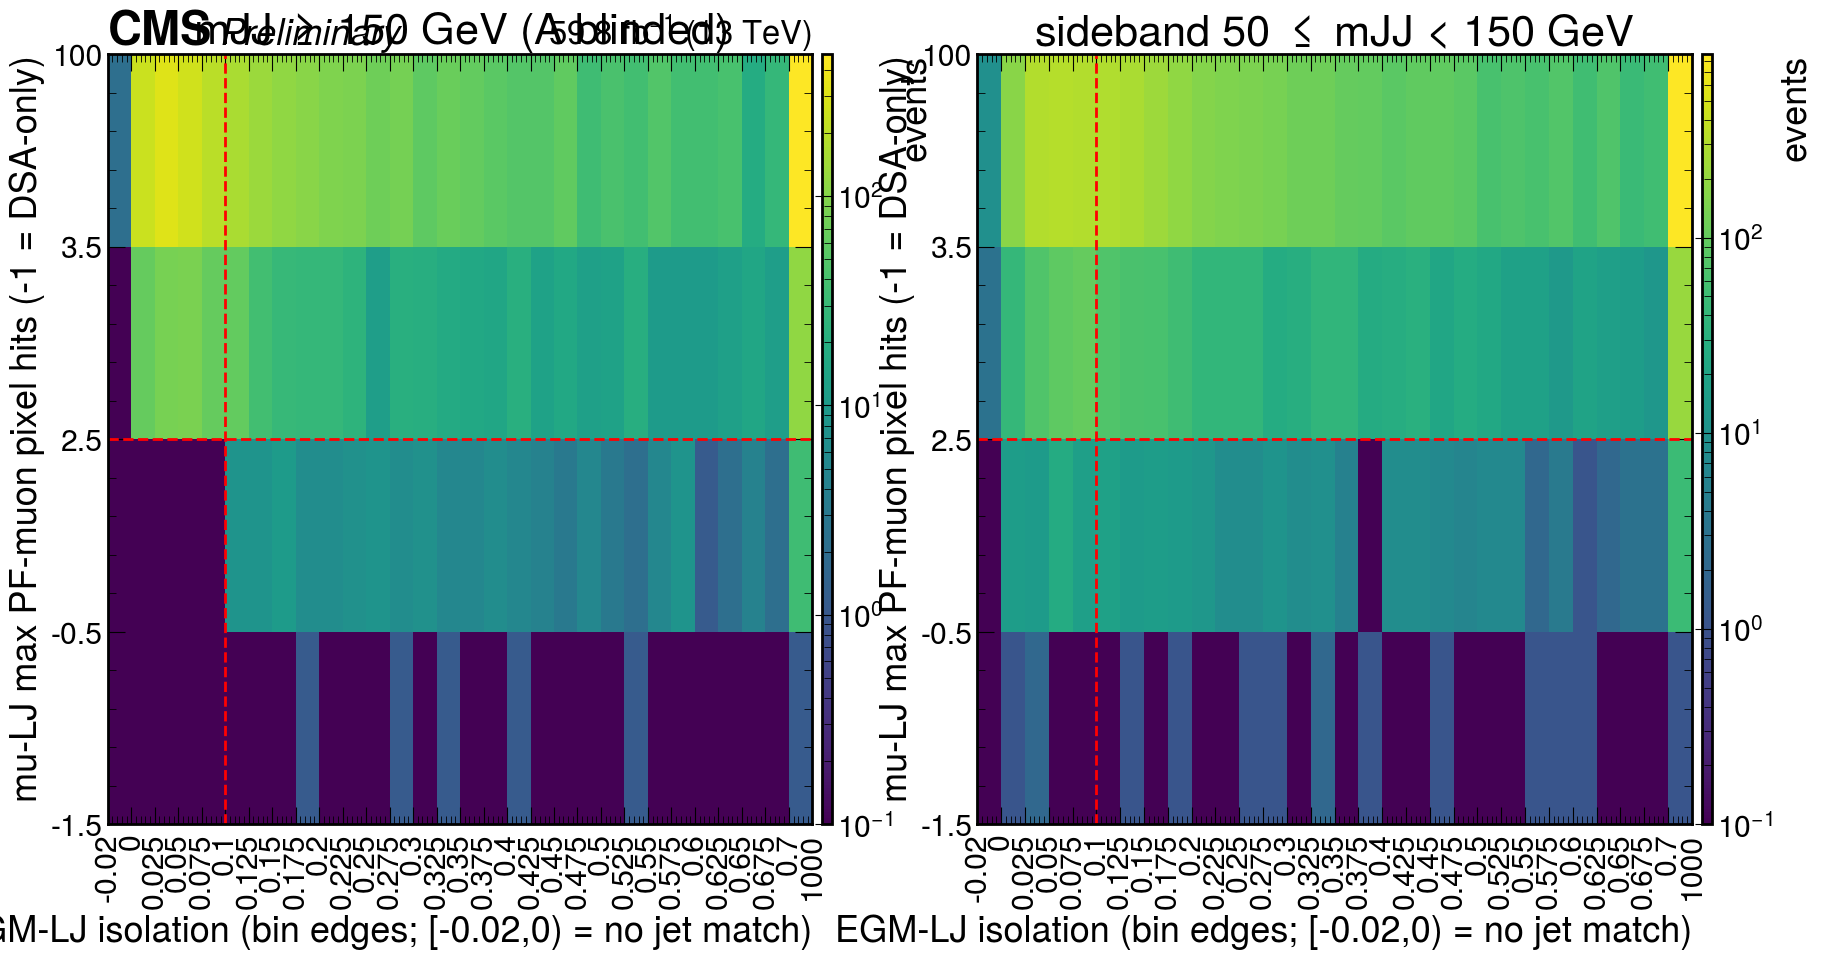

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.CMS)

def plane_2mu2e(mjj_lo, mjj_hi=None):
    '''(egmiso, mudisp) counts with all other SR cuts applied, mJJ in [lo, hi).
    mjj_hi=None means "up to and including the overflow region".'''
    jhi = len(e2["mjj"]) - 1 if mjj_hi is None else eix(e2["mjj"], mjj_hi)
    s = {"muiso":  slice(0, eix(e2["muiso"], 0.25), sum),
         "dphi":   slice(eix(e2["dphi"], 2.0), len(e2["dphi"]) - 1, sum),
         "egmdisp": slice(eix(e2["egmdisp"], 0.5), len(e2["egmdisp"]) - 1, sum),
         "mjj":    slice(eix(e2["mjj"], mjj_lo), jhi, sum),
         "parity": sum}
    hh = h2[s]
    v = hh.view()["value"]
    names = [a.name for a in hh.axes]
    if names != ["egmiso", "mudisp"]:
        v = v.T
    return v

vSR = plane_2mu2e(150., None)
vSB = plane_2mu2e(50., 150.)
xe, ye = e2["egmiso"], e2["mudisp"]

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
for axp, v, title in [(axs[0], vSR, "mJJ $\\geq$ 150 GeV (A blinded)"),
                      (axs[1], vSB, "sideband 50 $\\leq$ mJJ < 150 GeV")]:
    pc = axp.pcolormesh(np.arange(len(xe)), np.arange(len(ye)), v.T + 0.1,
                        norm=matplotlib.colors.LogNorm(), cmap="viridis")
    axp.axvline(eix(xe, 0.10), color="red", ls="--", lw=2)
    axp.axhline(eix(ye, 2.5), color="red", ls="--", lw=2)
    axp.set_xticks(range(len(xe)))
    axp.set_xticklabels(["%g" % x for x in xe], rotation=90)
    axp.set_yticks(range(len(ye)))
    axp.set_yticklabels(["%g" % y for y in ye])
    axp.set_xlabel("EGM-LJ isolation (bin edges; [-0.02,0) = no jet match)")
    axp.set_ylabel("mu-LJ max PF-muon pixel hits (-1 = DSA-only)")
    axp.set_title(title)
    cax = hep.utils.append_axes(axp, extend=True)
    fig.colorbar(pc, cax=cax, label="events")
hep.cms.label("Preliminary", data=True, lumi=59.8, ax=axs[0])
plt.show()

The prediction and the sideband closure:

In [5]:
# Region counts at mJJ >= 150 (A blind):
B = quad_2mu2e(False, True)    # egm-LJ NOT isolated, mu-LJ displaced-like
Cc = quad_2mu2e(True, False)   # egm-LJ isolated,     mu-LJ prompt-like
D = quad_2mu2e(False, False)   # neither
pred = B * Cc / D
stat = pred * math.sqrt(1/B + 1/Cc + 1/D)
print("Signal-region prediction (A blinded):")
print("  B=%.0f  C=%.0f  D=%.0f" % (B, Cc, D))
print("  A_pred = B*C/D = %.1f +- %.1f (stat) +- %.1f (14%% closure syst)"
      % (pred, stat, 0.14 * pred))

# Closure in the mJJ sideband, where A is open:
def quad_SB(egm_pass, mud_pass, lo=50., hi=150.):
    s = {"muiso":  slice(0, eix(e2["muiso"], 0.25), sum),
         "dphi":   slice(eix(e2["dphi"], 2.0), len(e2["dphi"]) - 1, sum),
         "egmdisp": slice(eix(e2["egmdisp"], 0.5), len(e2["egmdisp"]) - 1, sum),
         "mjj":    slice(eix(e2["mjj"], lo), eix(e2["mjj"], hi), sum),
         "parity": sum}
    s["egmiso"] = (slice(0, eix(e2["egmiso"], 0.10), sum) if egm_pass
                   else slice(eix(e2["egmiso"], 0.10), len(e2["egmiso"]) - 1, sum))
    s["mudisp"] = (slice(0, eix(e2["mudisp"], 2.5), sum) if mud_pass
                   else slice(eix(e2["mudisp"], 2.5), len(e2["mudisp"]) - 1, sum))
    return val(h2[s])

sA, sB, sC, sD = quad_SB(True, True), quad_SB(False, True), quad_SB(True, False), quad_SB(False, False)
R = sA * sD / (sB * sC)
dR = R * math.sqrt(1/sA + 1/sB + 1/sC + 1/sD)
print("\nSideband closure (50 <= mJJ < 150, A open):")
print("  A=%.0f B=%.0f C=%.0f D=%.0f  ->  R = A*D/(B*C) = %.3f +- %.3f" % (sA, sB, sC, sD, R, dR))

# The same closure split into the two halves of the sideband, to bound how much
# the closure depends on mJJ (the extrapolation to mJJ >= 150 is the method's
# main assumption):
for lo, hi in [(50., 100.), (100., 150.)]:
    wA, wB = quad_SB(True, True, lo, hi), quad_SB(False, True, lo, hi)
    wC, wD = quad_SB(True, False, lo, hi), quad_SB(False, False, lo, hi)
    wR = wA * wD / (wB * wC)
    wdR = wR * math.sqrt(sum(1 / max(x, 1) for x in (wA, wB, wC, wD)))
    print("  mJJ [%3.0f, %3.0f): A=%.0f B=%.0f C=%.0f D=%.0f  ->  R = %.3f +- %.3f"
          % (lo, hi, wA, wB, wC, wD, wR, wdR))

# Supplementary: the weighted correlation of the two plane variables across the
# sideband, on bin indices with the sentinel bins excluded (they are categories,
# not values).
ix0, iy0 = eix(xe, 0.0), eix(ye, -0.5)
vv = vSB[ix0:, iy0:]
xi, yi = np.meshgrid(np.arange(vv.shape[0]), np.arange(vv.shape[1]), indexing="ij")
w = vv.flatten(); xi, yi = xi.flatten(), yi.flatten()
mx, my = np.average(xi, weights=w), np.average(yi, weights=w)
r_corr = (np.average((xi - mx) * (yi - my), weights=w)
          / math.sqrt(np.average((xi - mx)**2, weights=w) * np.average((yi - my)**2, weights=w)))
print("\nWeighted bin-index correlation of (egmiso, mudisp) in the sideband,")
print("  sentinel bins excluded: r = %+.3f  (N = %.0f events)" % (r_corr, w.sum()))

Signal-region prediction (A blinded):
  B=166  C=1316  D=2635
  A_pred = B*C/D = 82.9 +- 7.0 (stat) +- 11.6 (14% closure syst)



Sideband closure (50 <= mJJ < 150, A open):
  A=73 B=241 C=1423 D=4703  ->  R = A*D/(B*C) = 1.001 +- 0.137


  mJJ [ 50, 100): A=23 B=73 C=491 D=1677  ->  R = 1.076 +- 0.263


  mJJ [100, 150): A=50 B=168 C=932 D=3026  ->  R = 0.966 +- 0.160

Weighted bin-index correlation of (egmiso, mudisp) in the sideband,
  sentinel bins excluded: r = +0.010  (N = 6413 events)


**What we quote, and the caveats we carry.** The 2mu2e background expectation in
the blinded signal region is $A_{pred} = B\cdot C/D$ with a statistical
uncertainty from the region counts and a **±14% closure systematic** — the
precision to which the 2018 sideband can test the factorization; the measured
central closure is consistent with 1.

Carried caveats, stated up front:

1. **Sideband-to-SR extrapolation.** Closure is measured at mJJ < 150 GeV and
   applied at mJJ ≥ 150 GeV. The split-window closures printed above bound the
   mJJ-dependence within the sideband, but the extrapolation itself is an
   assumption of the method — one reason Part 3 also pursues mJJ-shape-based
   methods.
2. **Era stability.** The per-era B-region rate rises monotonically through
   2018 (quantified in Part 2, Section 7). The timing is consistent with the
   HEM15/16 calorimeter failure (two HCAL-endcap sectors lost power partway
   through 2018) — an attribution we treat as a hypothesis, not a demonstrated
   mechanism. The per-era closure is compatible with the combined value in
   three of four eras; 2018C is low (R = 0.22 ± 0.16; a Poisson
   likelihood-ratio test across the four eras gives p ≈ 0.04 — Part 2,
   Section 7). We carry this as a documented tension.
3. **Plane choice.** An alternative axis pairing (EGM-LJ isolation × mJJ)
   predicts a value 39% below the deployed plane's (Part 2, Section 7). This
   spread is *not* covered by the ±14% closure precision — it is an additional
   systematic that the Part-3 shape-based methods are designed to resolve.
4. The prediction uses the **sentinel-in** convention on both axes (the
   "no jet match" isolation bin counts as isolated; mudisp $-1$ counts as
   displaced-like). This was fixed before unblinding B/C/D; Part 2 documents the
   sensitivity of every result to this convention.

## 8. Where this leaves us

* **2mu2e**: an ABCD estimate on egmiso × mudisp is deployed, with the numbers
  above. It is a *working* background estimate: closure holds at the precision
  the 2018 data allows.
* **4mu**: none of this works — despite the channel being superficially the
  simpler one. Part 2 shows, at full 2018 statistics, that *every*
  isolation-based ABCD plane fails closure in 4mu; that the isolated corner is
  dominated by a jet-unmatched, DSA-only, back-to-back instrumental population
  invisible to MC; that a dimuon-vertex discriminant separates that population
  from displaced signal; and that even after vertex cleaning a genuine
  isolation–isolation–mJJ correlation among real muon pairs breaks the
  factorization.
* **Part 3** therefore tests three non-ABCD methods on a dedicated fine-binned
  mJJ campaign, in **both** channels, aiming at a single unified background
  method: a smooth-shape **bump-hunt** on the vertex-cleaned mJJ spectrum
  (signal is a resonance, background is smooth), an **MC-assisted** shape
  comparison, and **transfer factors** measured as a function of mJJ.